# Provisionnement - Assurance Non Vie

L'objectif de ce projet est d'appliquer différentes méthodes de provisionnement à un jeu de données acturiels issu du site [casact.org](https://www.casact.org/publications-research/research/research-resources/loss-reserving-data-pulled-naic-schedule-p) afin de calculer l'IBNR à une année donnée.

# Sommaire

* [Packages](#partie1)
* [Import des données](#partie2)
* [Triangle de liquidation](#partie3)
* [Méthode Chain-Ladder](#partie4)
* [Méthode Loss-Ratio](#partie5)
* [Méthode Bornhuetter-Ferguson](#partie6)
* [Vérification des hypothèses](#partie7)
* [Backtesting: RMSE - MAE - MAPE](#partie8)

## Packages <a id="partie1"></a>

In [17]:
# %pip install chainladder

import locale
import warnings
import pandas as pd
import numpy as np
import chainladder as cl
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

%matplotlib inline
warnings.filterwarnings('ignore')

## Import des données <a id="partie2"></a>

In [18]:
df = pd.read_csv("wkcomp_pos_98-07.csv")
df.head(5)

,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007
0,86,Allstate Ins Co Grp,1998,1998,1,10079,1201,1518,7133,-860,7993,0,135699.214
1,86,Allstate Ins Co Grp,1998,1999,2,9643,2652,240,7133,-860,7993,0,135699.214
2,86,Allstate Ins Co Grp,1998,2000,3,3207,3172,13,7133,-860,7993,0,135699.214
3,86,Allstate Ins Co Grp,1998,2001,4,3202,3178,8,7133,-860,7993,0,135699.214
4,86,Allstate Ins Co Grp,1998,2002,5,3197,3180,8,7133,-860,7993,0,135699.214


## Triangle de liquidation <a id="partie3"></a>

In [19]:
# Certaines méthodes du package chainladder ne fonctionnent qu'avec une horloge 
# anglophone sur la machine. On regle donc ce probleme manuellement dans le notebook. 

locale.setlocale(locale.LC_TIME, 'English_United States.1252')
print(locale.getlocale(locale.LC_TIME))

('English_United States', '1252')


In [20]:
# Chargement des sinistres survenus (IncurredLosses) avec Chainladder

incurredLosses_data = cl.Triangle(
    df,
    origin="AccidentYear",
    development="DevelopmentYear",
    columns="IncurredLosses",
    index=["GRNAME"]
)
incurredLosses_data

,Triangle Summary
Valuation:,2016-12
Grain:,OYDY
Shape:,"(132, 1, 19, 19)"
Index:,[GRNAME]
Columns:,[IncurredLosses]


In [21]:
# Sommes des montants sur l'index "GRNAME" et passage à des valeurs cumulatives

incurredLosses = incurredLosses_data.sum().loc[:, :, "1998":"2007", :120].incr_to_cum().dropna()
incurredLosses

,12,24,36,48,60,72,84,96,108,120
1998,"1,474,384","2,956,897","4,407,489","5,834,174","7,250,711","8,666,008","10,094,283","11,531,774","12,983,881","14,438,098"
1999,"1,544,524","3,081,128","4,632,230","6,197,068","7,773,405","9,379,374","11,028,768","12,683,132","14,385,367","16,088,915"
2000,"1,623,212","3,319,103","5,037,891","6,775,389","8,535,552","10,316,198","12,115,135","13,920,190","15,735,471","17,552,132"
2001,"1,821,092","3,648,373","5,511,198","7,388,004","9,278,363","11,181,447","13,123,219","15,072,576","17,037,394","19,014,458"
2002,"1,970,128","4,015,975","6,060,973","8,108,033","10,153,985","12,186,107","14,218,726","16,250,405","18,281,436","20,306,770"
2003,"2,361,158","4,661,459","6,907,721","9,125,479","11,302,482","13,481,827","15,610,153","17,732,002","19,852,667","21,980,285"
2004,"2,693,419","5,229,679","7,661,394","10,005,005","12,301,674","14,578,511","16,838,091","19,086,405","21,338,986","23,591,838"
2005,"2,843,577","5,469,101","7,967,425","10,408,980","12,803,562","15,171,279","17,531,805","19,891,700","22,264,625","24,610,018"
2006,"2,810,373","5,528,934","8,146,451","10,698,887","13,205,810","15,693,292","18,166,404","20,648,326","23,106,153","25,537,981"
2007,"2,389,599","4,754,680","7,065,131","9,319,718","11,546,546","13,762,231","15,974,789","18,172,772","20,365,959","22,551,770"


In [22]:
# Séparation du triangle supérieur (données d'entrainement)

triangle_sup = incurredLosses[incurredLosses.valuation < pd.to_datetime('2008-12-31')]
triangle_sup

,12,24,36,48,60,72,84,96,108,120
1998,"1,474,384","2,956,897","4,407,489","5,834,174","7,250,711","8,666,008","10,094,283","11,531,774","12,983,881","14,438,098"
1999,"1,544,524","3,081,128","4,632,230","6,197,068","7,773,405","9,379,374","11,028,768","12,683,132","14,385,367",
2000,"1,623,212","3,319,103","5,037,891","6,775,389","8,535,552","10,316,198","12,115,135","13,920,190",,
2001,"1,821,092","3,648,373","5,511,198","7,388,004","9,278,363","11,181,447","13,123,219",,,
2002,"1,970,128","4,015,975","6,060,973","8,108,033","10,153,985","12,186,107",,,,
2003,"2,361,158","4,661,459","6,907,721","9,125,479","11,302,482",,,,,
2004,"2,693,419","5,229,679","7,661,394","10,005,005",,,,,,
2005,"2,843,577","5,469,101","7,967,425",,,,,,,
2006,"2,810,373","5,528,934",,,,,,,,
2007,"2,389,599",,,,,,,,,


In [23]:
# Chargement des données sur la prime pure nette (EarnedPremNet) avec Chainladder

premium_data = cl.Triangle(
    df,
    origin="AccidentYear",
    development="DevelopmentYear",
    columns="EarnedPremNet",
    index=["GRNAME"]
)

premium = premium_data.sum().loc[:, :, "1998":"2007", :120].incr_to_cum().dropna()
premium = premium[premium.valuation < pd.to_datetime('2008-12-31')].latest_diagonal

premium

,2007
1998,"19,941,840"
1999,"18,514,431"
2000,"18,271,376"
2001,"10,473,610"
2002,"17,045,556"
2003,"17,036,910"
2004,"16,122,084"
2005,"13,356,606"
2006,"8,887,736"
2007,"3,540,362"


## Méthode Chain-Ladder <a id="partie4"></a>

On fait ici une comparaison entre :
- Mack : formule analytique fermée (moyenne + écart-type)
- Bootstrap ODP : simulation empirique (distribution complète)

In [24]:
# MACK CHAINLADDER

# Fitting des hyperparamètres puis du modèle
dev = cl.Development(average='volume').fit_transform(triangle_sup)
mcl = cl.MackChainladder().fit(dev)

print("\nIBNR par origine :")
print(mcl.ibnr_.to_frame())

# Résumé global (IBNR total, erreur standard totale)
ibnr_val = float(mcl.ibnr_.sum('origin'))
std_val = float(mcl.total_mack_std_err_.values[0][0])

print(f"\nIBNR total (Mack)        : {ibnr_val:,.0f}")
print(f"Erreur standard totale    : {std_val:,.0f}")

# Intervalle de confiance approximatif à 95% (hypothèse de normalité)
ic_bas = ibnr_val - 1.96 * std_val
ic_haut = ibnr_val + 1.96 * std_val
print(f"IC 95% (approx. normal)  : [{ic_bas:,.0f} ; {ic_haut:,.0f}]")


IBNR par origine :
                    2261
1998-01-01           NaN
1999-01-01  1.611186e+06
2000-01-01  3.575485e+06
2001-01-01  5.800803e+06
2002-01-01  8.416621e+06
2003-01-01  1.168974e+07
2004-01-01  1.544038e+07
2005-01-01  1.895352e+07
2006-01-01  2.227061e+07
2007-01-01  2.140608e+07

IBNR total (Mack)        : 109,164,425
Erreur standard totale    : 1,494,213
IC 95% (approx. normal)  : [106,235,769 ; 112,093,082]


In [25]:
# BOOTSTRAP ODP SAMPLE

# Génère N_SIMS triangles simulés par rééchantillonnage des résidus de Pearson
N_SIMS = 2000
sims = cl.BootstrapODPSample(
    n_sims=N_SIMS,
    random_state=42
).fit_transform(triangle_sup)

# Fit du Chainladder classique sur TOUTES les simulations d'un coup
model_boot = cl.Chainladder().fit(sims)

# Distribution complète de l'IBNR total (une valeur par simulation)
ibnr_dist = model_boot.ibnr_.sum('origin').to_frame()

print(f"\nNombre de simulations    : {N_SIMS}")
print(f"IBNR moyen (Bootstrap)   : {ibnr_dist.values.mean():,.0f}")
print(f"Écart-type (Bootstrap)   : {ibnr_dist.values.std():,.0f}")

# Quantiles empiriques (plus riches qu'une simple IC normale)
q05 = np.percentile(ibnr_dist.values, 5)
q50 = np.percentile(ibnr_dist.values, 50)
q95 = np.percentile(ibnr_dist.values, 95)

print(f"\nQuantiles empiriques de l'IBNR :")
print(f"  5%  : {q05:,.0f}")
print(f"  50% (médiane) : {q50:,.0f}")
print(f"  95% : {q95:,.0f}")


Nombre de simulations    : 2000
IBNR moyen (Bootstrap)   : 109,235,941
Écart-type (Bootstrap)   : 1,669,381

Quantiles empiriques de l'IBNR :
  5%  : 106,433,974
  50% (médiane) : 109,269,060
  95% : 112,011,913


In [26]:
# Comparaison des deux méthodes

comparaison = pd.DataFrame({
    'Mack (analytique)': [ibnr_val, std_val, ic_bas, ic_haut],
    'Bootstrap (empirique)': [ibnr_dist.values.mean(), ibnr_dist.values.std(), q05, q95],
}, index=['IBNR total moyen', 'Écart-type', 'Borne basse (~5%)', 'Borne haute (~95%)'])

print(comparaison.round(0))

                    Mack (analytique)  Bootstrap (empirique)
IBNR total moyen          109164425.0            109235941.0
Écart-type                  1494213.0              1669381.0
Borne basse (~5%)         106235769.0            106433974.0
Borne haute (~95%)        112093082.0            112011913.0



Graphique enregistré : mack_vs_bootstrap.png


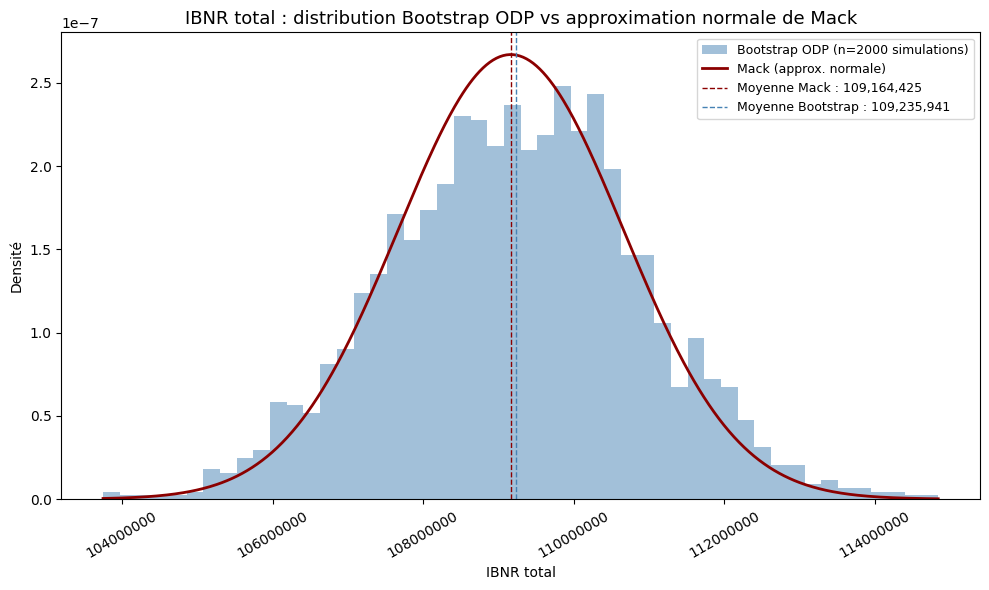

In [27]:
# Visualisation combinée

fig, ax = plt.subplots(figsize=(10, 6))

# Bootstrap : histogramme de la distribution empirique
ax.hist(
    ibnr_dist.values.flatten(),
    bins=50,
    density=True,
    alpha=0.5,
    color='steelblue',
    label=f'Bootstrap ODP (n={N_SIMS} simulations)'
)

# Mack : courbe normale théorique (moyenne + écart-type)
x = np.linspace(
    min(ibnr_dist.values.min(), ic_bas),
    max(ibnr_dist.values.max(), ic_haut),
    500
)
pdf_mack = norm.pdf(x, loc=ibnr_val, scale=std_val)
ax.plot(x, pdf_mack, color='darkred', linewidth=2, label='Mack (approx. normale)')

# Repères verticaux : moyennes des deux méthodes
ax.axvline(ibnr_val, color='darkred', linestyle='--', linewidth=1,
           label=f'Moyenne Mack : {ibnr_val:,.0f}')
ax.axvline(ibnr_dist.values.mean(), color='steelblue', linestyle='--', linewidth=1,
           label=f'Moyenne Bootstrap : {ibnr_dist.values.mean():,.0f}')

ax.set_title("IBNR total : distribution Bootstrap ODP vs approximation normale de Mack",
             fontsize=13)
ax.set_xlabel("IBNR total")
ax.set_ylabel("Densité")
ax.legend(loc='upper right', fontsize=9)
ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('mack_vs_bootstrap.png', dpi=150)
print("\nGraphique enregistré : mack_vs_bootstrap.png")
plt.show()

## Méthode Loss-Ratio <a id="partie5"></a>

La méthode Loss-Ratio calcule l'IBNR avec la formule suivante :
- Charge Ultime = Apriori (loss ratio a priori) x Prime acquise
- IBNR = Charge Ultime - Incurred Losses to Date

On fait ici une comparaison entre :
- Loss-Ratio déterministe (point estimate classique, apriori fixe)
- Loss-Ratio stochastique (Bootstrap ODP sur les résidus + apriori_sigma qui traite l'apriori lui-même comme une variable aléatoire)

In [28]:
APRIORI = 0.65        # loss ratio a priori (hypothèse métier / marché)
APRIORI_SIGMA = 0.10  # incertitude sur l'apriori lui-même (10%)
N_SIMS = 2000

In [29]:
# LOSS-RATIO DÉTERMINISTE (Benktander n_iters=0 = ELR pur)

lr_det = cl.Benktander(apriori=APRIORI, n_iters=0).fit(
    triangle_sup, sample_weight=premium
)

ibnr_det = float(lr_det.ibnr_.sum('origin'))

print(f"IBNR total (Loss-Ratio)     : {ibnr_det:,.0f}")
print("(NB: l'Ultimate ne dépend ici QUE de apriori x prime, "
      "pas du payé observé)")

IBNR total (Loss-Ratio)     : -12,172,594
(NB: l'Ultimate ne dépend ici QUE de apriori x prime, pas du payé observé)


In [30]:
# LOSS-RATIO STOCHASTIQUE (Bootstrap + apriori aléatoire)

# On simule N_SIMS triangles alternatifs par bootstrap des résidus
# (utile surtout pour l'IBNR, puisque l'Ultimate lui-même ne dépend pas
#  du payé -- mais l'IBNR = Ultimate - payé simulé en dépend bien)
sim = cl.BootstrapODPSample(random_state=42, n_sims=N_SIMS)
sim.fit(triangle_sup, sample_weight=premium)

# Fitting Loss-Ratio (Benktander n_iters=0) sur les triangles simulés,
# avec apriori_sigma qui fait varier l'apriori lui-même à chaque simulation
model_boot = cl.Benktander(
    apriori=APRIORI, n_iters=0, apriori_sigma=APRIORI_SIGMA
).fit(sim.resampled_triangles_, sample_weight=premium)

# Distribution complète de l'IBNR (une valeur par simulation)
ibnr_dist = model_boot.ibnr_.sum('origin').to_frame()

print(f"\nNombre de simulations       : {N_SIMS}")
print(f"IBNR moyen (Bootstrap)      : {ibnr_dist.values.mean():,.0f}")
print(f"Écart-type (Bootstrap)      : {ibnr_dist.values.std():,.0f}")

q05 = np.percentile(ibnr_dist.values, 5)
q50 = np.percentile(ibnr_dist.values, 50)
q95 = np.percentile(ibnr_dist.values, 95)

print(f"\nQuantiles empiriques de l'IBNR :")
print(f"  5%  : {q05:,.0f}")
print(f"  50% (médiane) : {q50:,.0f}")
print(f"  95% : {q95:,.0f}")


Nombre de simulations       : 2000
IBNR moyen (Bootstrap)      : -12,042,653
Écart-type (Bootstrap)      : 14,644,597

Quantiles empiriques de l'IBNR :
  5%  : -36,187,290
  50% (médiane) : -11,834,211
  95% : 11,752,257


In [31]:
# Comparaison

comparaison = pd.DataFrame({
    'Loss-Ratio déterministe': [ibnr_det, np.nan, np.nan, np.nan],
    'Loss-Ratio stochastique (Bootstrap)': [
        ibnr_dist.values.mean(), ibnr_dist.values.std(), q05, q95
    ],
}, index=['IBNR moyen', 'Écart-type', 'Borne basse (~5%)', 'Borne haute (~95%)'])

print(comparaison.round(0))

                    Loss-Ratio déterministe  \
IBNR moyen                      -12172594.0   
Écart-type                              NaN   
Borne basse (~5%)                       NaN   
Borne haute (~95%)                      NaN   

                    Loss-Ratio stochastique (Bootstrap)  
IBNR moyen                                  -12042653.0  
Écart-type                                   14644597.0  
Borne basse (~5%)                           -36187290.0  
Borne haute (~95%)                           11752257.0  



Graphique enregistré : lossratio_det_vs_stochastique.png


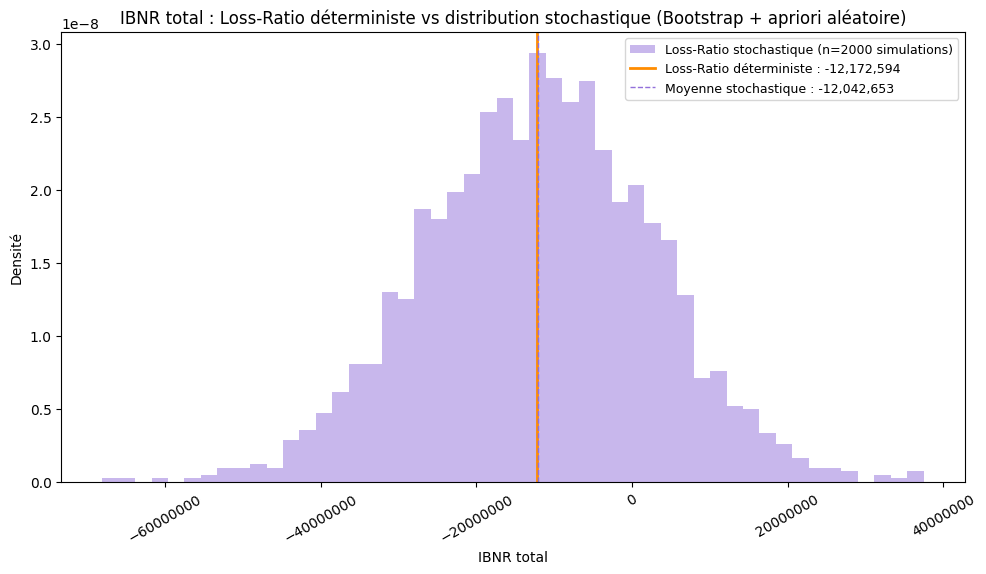

In [32]:
# Visualisation combinée

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    ibnr_dist.values.flatten(),
    bins=50,
    density=True,
    alpha=0.5,
    color='mediumpurple',
    label=f'Loss-Ratio stochastique (n={N_SIMS} simulations)'
)

ax.axvline(
    ibnr_det, color='darkorange', linewidth=2,
    label=f'Loss-Ratio déterministe : {ibnr_det:,.0f}'
)
ax.axvline(
    ibnr_dist.values.mean(), color='mediumpurple', linestyle='--', linewidth=1,
    label=f'Moyenne stochastique : {ibnr_dist.values.mean():,.0f}'
)

ax.set_title(
    "IBNR total : Loss-Ratio déterministe vs distribution stochastique "
    "(Bootstrap + apriori aléatoire)",
    fontsize=12
)
ax.set_xlabel("IBNR total")
ax.set_ylabel("Densité")
ax.legend(loc='upper right', fontsize=9)
ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('lossratio_det_vs_stochastique.png', dpi=150)
print("\nGraphique enregistré : lossratio_det_vs_stochastique.png")
plt.show()

## Méthode Bornhuetter-Ferguson <a id="partie6"></a>

On fait ici une comparaison entre :
- BF déterministe (point estimate classique, apriori fixe)
- BF stochastique (Bootstrap ODP sur les résidus + apriori_sigma qui traite l'apriori lui-même comme une variable aléatoire)

In [33]:
APRIORI = 0.65        # loss ratio a priori (hypothèse métier / marché)
APRIORI_SIGMA = 0.10  # incertitude sur l'apriori lui-même (10%)
N_SIMS = 2000

In [34]:
# BORNHUETTER-FERGUSON DÉTERMINISTE

bf_det = cl.BornhuetterFerguson(apriori=APRIORI).fit(
    triangle_sup, sample_weight=premium
)

ibnr_det = float(bf_det.ibnr_.sum('origin'))
print(f"IBNR total (BF déterministe)     : {ibnr_det:,.0f}")

IBNR total (BF déterministe)     : 35,052,017


In [35]:
# BORNHUETTER-FERGUSON STOCHASTIQUE (Bootstrap + apriori_sigma)

# On simule N_SIMS triangles alternatifs par bootstrap des résidus
sim = cl.BootstrapODPSample(random_state=42, n_sims=N_SIMS)
sim.fit(triangle_sup, sample_weight=premium)

# Fitting BF sur les triangles simulés
# apriori_sigma fait varier l'apriori lui-même à chaque simulation
# (tiré aléatoirement autour de APRIORI avec un écart-type de APRIORI_SIGMA)
model_boot = cl.BornhuetterFerguson(
    apriori=APRIORI, apriori_sigma=APRIORI_SIGMA
).fit(sim.resampled_triangles_, sample_weight=premium)

# Distribution complète de l'IBNR (une valeur par simulation)
ibnr_dist = model_boot.ibnr_.sum('origin').to_frame()

print(f"\nNombre de simulations       : {N_SIMS}")
print(f"IBNR moyen (Bootstrap)      : {ibnr_dist.values.mean():,.0f}")
print(f"Écart-type (Bootstrap)      : {ibnr_dist.values.std():,.0f}")

q05 = np.percentile(ibnr_dist.values, 5)
q50 = np.percentile(ibnr_dist.values, 50)
q95 = np.percentile(ibnr_dist.values, 95)

print(f"\nQuantiles empiriques de l'IBNR :")
print(f"  5%  : {q05:,.0f}")
print(f"  50% (médiane) : {q50:,.0f}")
print(f"  95% : {q95:,.0f}")


Nombre de simulations       : 2000
IBNR moyen (Bootstrap)      : 35,075,316
Écart-type (Bootstrap)      : 5,579,635

Quantiles empiriques de l'IBNR :
  5%  : 25,658,155
  50% (médiane) : 34,975,448
  95% : 43,961,235


In [36]:
# Comparaison

comparaison = pd.DataFrame({
    'BF déterministe': [ibnr_det, np.nan, np.nan, np.nan],
    'BF stochastique (Bootstrap)': [
        ibnr_dist.values.mean(), ibnr_dist.values.std(), q05, q95
    ],
}, index=['IBNR moyen', 'Écart-type', 'Borne basse (~5%)', 'Borne haute (~95%)'])

print(comparaison.round(0))

                    BF déterministe  BF stochastique (Bootstrap)
IBNR moyen               35052017.0                   35075316.0
Écart-type                      NaN                    5579635.0
Borne basse (~5%)               NaN                   25658155.0
Borne haute (~95%)              NaN                   43961235.0



Graphique enregistré : bf_det_vs_stochastique.png


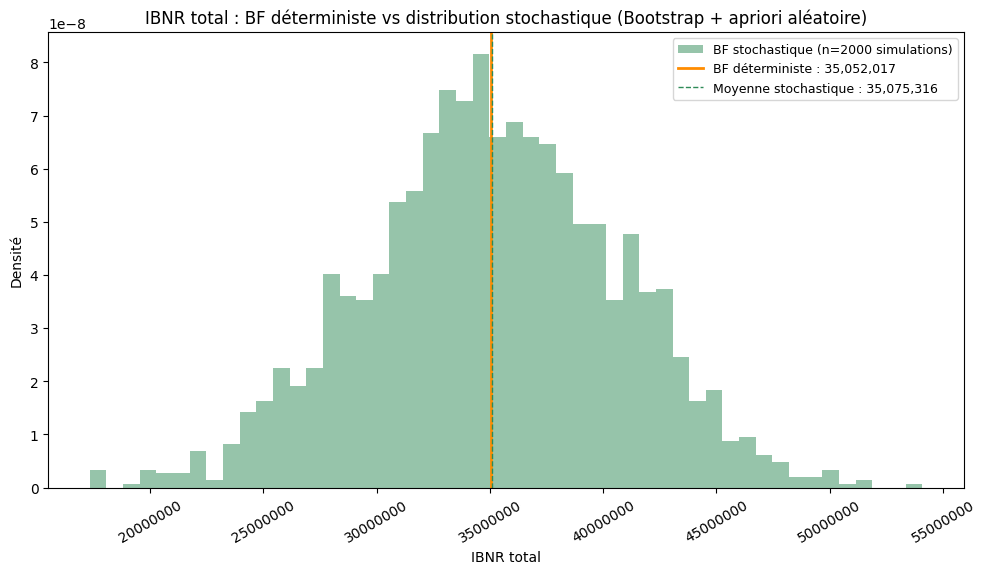

In [37]:
# Visualisation combinée

fig, ax = plt.subplots(figsize=(10, 6))

# Distribution stochastique (Bootstrap + apriori_sigma)
ax.hist(
    ibnr_dist.values.flatten(),
    bins=50,
    density=True,
    alpha=0.5,
    color='seagreen',
    label=f'BF stochastique (n={N_SIMS} simulations)'
)

# Point estimate déterministe : simple ligne verticale (pas de courbe,
# puisqu'il n'y a pas de formule analytique d'erreur standard type Mack)
ax.axvline(
    ibnr_det, color='darkorange', linewidth=2,
    label=f'BF déterministe : {ibnr_det:,.0f}'
)
ax.axvline(
    ibnr_dist.values.mean(), color='seagreen', linestyle='--', linewidth=1,
    label=f'Moyenne stochastique : {ibnr_dist.values.mean():,.0f}'
)

ax.set_title(
    "IBNR total : BF déterministe vs distribution stochastique "
    "(Bootstrap + apriori aléatoire)",
    fontsize=12
)
ax.set_xlabel("IBNR total")
ax.set_ylabel("Densité")
ax.legend(loc='upper right', fontsize=9)
ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('bf_det_vs_stochastique.png', dpi=150)
print("\nGraphique enregistré : bf_det_vs_stochastique.png")
plt.show()

## Vérification des hypothèses <a id="partie7"></a>

## Backtesting: RMSE - MAE - MAPE <a id="partie8"></a>

In [ ]:
# chainladder.TailCurve
# Solvabilité II q99.5
# Hypothèses à vérifier
# Backtesting sur les full_triangles